<a href="https://colab.research.google.com/github/nicolejanoff/PRO1-CB2330/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJECT CARD:

**The paper:** Barretina, J. et al. (2012) The Cancer Cell Line Encyclopedia enables predictive modelling of anticancer drug sensitivity. Nature 483:603-607.
https://doi.org/10.1038/nature11003

---

**The data object:**

The project uses pharmacological dose-response data (drug concentrations and average empirical valus ) from Supplementary Table S11 for three different cancer lineages:
- Bone Cancer ($\text{EC}_{50,\text{ True}} = 0.0175\,\mu\text{M}, \sigma = 0.04$)
- Breast Cancer ($\text{EC}_{50,\text{ True}} = 0.0969\,\mu\text{M}, \sigma = 0.05$)
- Skin cancer ($\text{EC}_{50,\text{ True}} = 0.2332\,\mu\text{M}, \sigma = 0.06$)

Only drug-response data for the HDAC inhibitor Panobinotat over a concentration range of (0.0025 to 8.0000 $\mu\text{M}$) was examined in the project.

---

**The random variable chosen:** The random variable that was chosen was the observed cell viability $Y_i$ given a drug concentration of $c_i$. $Y_i$ is modelled as a continuous Gaussian random variable according to the following equation:

$$Y_i \sim \mathcal{N}\left(\text{Hill}(c_i, \text{EC}_{50}), \sigma^2\right)$$

---

**What the paper does:** The paper describes the Cell Cancer Line Encyclopedia (CLLE) which is a compilation of data from hundreds of human cancer cell lines. The data contains information about the cell lines gene expression, chromosomal copy number and massively parallel sequencing data . The paper also profiled 24 different anti-cancer drugs by measuring the cells' response to them (EC50, IC50 and Activity).


When the profiles of the anticancer drugs and the human cancer cell lines were coupled it enabled the identifications of genomic features which influence the drug sensitivity of the cells. The results indicated that annotated cell-line collections could help in the preclinical stratification of anti-cancer drugs and could aid in the emergence of individualized therapeutics.

---

**The generative model proposed:** The model used to model the drug response to is a the Hill equations simplified to two parameters, EC50 and c:

Original Hill equation:

$$\text{Viability}(c) = E_{\min} + \frac{E_{\max} - E_{\min}}{1 + \left(\frac{c}{\text{EC}_{50}}\right)^h}$$

Simplified Hill Equation:

$$\text{Hill}(c, \text{EC}_{50}) = \frac{1.0}{1.0 + \frac{c}{\text{EC}_{50}}}$$

Gaussian errors (noise) were also added to the equation to represent the experimental uncertainty in a real experiment:

Final model: $Y_{\text{observed}} = \text{Hill}(c, \text{EC}_{50}) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)$

---

**Parameters and assumptions:**

The parameters used are:

- EC50 which gives the drug concentration that results in a halvation of the cell viability.

- The standard deviation, $\sigma$
- Drug concentration, c

Due to the simplification of the Hill equation the model assumes the following:
- The Hill coefficient (slope, h=1) is fixed. This assumes that Panobinostat binds to a single receptor in the cell.
- Gaussian error distribution: Assumes that the measurement errors are independent and normally distributed for all examined concentration levels.
- The viability is normalized as the Hill equation generates values between 0-1.

---

**The forward simulation:**

The model simulates the cell viability observations over 8 different concentrations by evaluating the simplified two-parameter Hill equation and adding Gaussian errors.

The simulation examines four different cases: one for each of the three cancer cell lines and one where the three cell lines are combined into one dataset.

A Monte Carlo (MC) simulation was performed using 500 forward simulations with randomly generated measurement noise. The variability in the simulated outputs was used to estimate the variance of the results under measurement noise.

---

**The parameterization/fitting:**
Two methods were used for parameter estimation and to investigate the uncertainty of the estimations: Maximum Likelihood Estimation (MLE) and Bayesian inference using Markov Chain Monte Carlo (MCMC).

MLE was used by minimizing the Negative Log-Liklihood (NLL) function. The method for minimizing the NLL value was an Adaptive Gradient Descent algorithm, adjusting step size based on whether NLL increased or decreased for each step.

Bayesian MCMC inference was used to estimate EC50 and the uncertainty of the estimate for each cancer type. The resulting posterior samples were used to characterize the uncertainty in the EC50 estimates.

---

**What/if the model adds to the paper:**

The original paper provides point measurements and statistic metrics derived from fixed dose-response curves. This project introduces a simplified probabilistic model of drug response based on a two-parameter Hill equation, including Gaussian measurement errors/noise. Bayesian inference using MCMC is used to estimate EC50 and evaluate the uncertainty of the estimates for each cancer cell line. MC simulations are used to investigate how measurement noise affects the observed cell viability and is also used to visualize the variability of the results.

The original paper demonstrates that models trained on cancer cell lines from a specific cancer type can perform differently from models trained on a dataset combining multiple cancer types:

_"Indeed, a classifier built using the entire cell-line
data set performed suboptimally when applied exclusively to
melanoma-derived cell lines (Fig. 2d), whereas a model built with only
melanoma cell lines performed better (Fig. 2d)."_

This finding inspired the project, although the scope was simplified and scaled down. The Hill curves give a simple illustration of the papers finding by illustrating the differences in drug response between the three cancer cell lines. Four cases are analyzed: three individual cancer cell lines representing breast, skin and bone cancer, respectively, and a fourth case in which data from all three cell lines are combined into a single dataset. By comparing the individual and combined cases, the differences between cell lines and how well they can be represented by a single fitted dose-response curve can be visualized.

Even though the project is simple, it can serve as a complement to the original paper by investigating the drug response using a probabilistic model. Additionally, it can be used to evaluate the difficulties that arise from combining data from different cancer cell lines.

---

**Model limitations/how it breaks:**

The proposed model in this project functions for simple simulations of how cell viability varies with drug concentration, but relies on mathematical assumptions that deviate from the real case.

The model assumes a fixed Hill slope (h=1) which can introduce errors in the forward simulation of the model. Real cell drug responses may exhibit different Hill slopes.

Biologically, the cell viability is constrained to the intervall [0, 1]. Because the errors modelled in this model is assumed to be additive and follow a Gaussian distribution, simulated viability near the 0 and 1 can produce results that exceed the natural contraits thus producing unrealistic results. These values could distort the NLL values and introduce some errors in the single forward simulation.



In [1]:
import random
import math
import matplotlib.pyplot as plt

# Set the random seed so we get the same random results every time we run the code (good to use for debugging)
random.seed(40)

# Data and parameters from the report were picked from Table S11.
# Chosen drug: Panobinostat
# Cancers under investigation: Bone, breast and skin

# Drug (Panobinostat) concentrations used in the simulated experiment (µM)
concentrations = [0.0025, 0.0080, 0.0250, 0.0800, 0.2500, 0.8000, 2.5300, 8.0000]

# Average (empirical) EC50 values (uM) and measurement uncertainty (sigma)
cancer_types = {
    "Bone Cancer": {"EC50_true": 0.0175, "sigma": 0.04, "color": "purple"},
    "Breast Cancer": {"EC50_true": 0.0969, "sigma": 0.05, "color": "deeppink"},
    "Skin Cancer": {"EC50_true": 0.2332, "sigma": 0.06, "color": "orange"}
}


In [2]:
# Generative model
# The Hill equation describes how cell viability changes depending on drug concentration
# EC50 is the concentration where the predicted viability is 50% of the maximum response
# In other words, EC50 is the concentration at half-maximal activity of the drug compound

def Hill(concentration, EC50):
    return 1.0 / (1.0 + concentration / EC50)

In [3]:
# Parameter estimation (NLL and adaptive gradient descent)
# We want to investigate how well a particular EC50 value explains the observed data

# NLL - how well a given EC50 value explains the observed data
def NLL(EC50, concentrations, observations, sigma):
    predicted = [] # Predicted response for each concentration
    for concentration in concentrations:
      prediction = Hill(concentration, EC50)
      predicted.append(prediction)

    squared_error = 0
    for i in range(len(observations)): # Calculate sum of squared errors
      error = observations[i] - predicted[i]
      squared_error = squared_error + error ** 2

    n = len(observations) # no. of observations

    NLL = (0.5 * n * math.log(2 * math.pi * sigma**2)) + (squared_error / (2 * sigma**2))

    return NLL

# Calculate the slope of the score function around the current EC50
def slope_at(score, theta, h=0.0001):
    return (score(theta + h) - score(theta - h)) / (2 * h)

# Adaptive gradient descent, looks for an EC50 value that minimizes the NLL
def descend_adaptive(score, theta, alpha, h=0.0001, tol=1e-3, max_steps=1000):
    path = [theta]

    for step in range(max_steps):
        slope = slope_at(score, theta, h) # Slope at the current EC50
        if abs(slope) < tol: # Stop if the slope is close to zero
            return path

        theta_try = theta - alpha * slope # Move in the opposite direction of the slope (to try new EC50 value)

        if score(theta_try) > score(theta): # If the new value gives a worse score, slow down
          alpha = alpha * 0.5 # Step size halved on a rise

        else: # If the new value gives a better score, speed up
          theta = theta_try
          alpha = alpha * 1.2 # Step size lengthened by 1.2 on a fall

        path.append(theta) # save current

    return path

# Fit EC50 with adaptive gradient descent
def fit_EC50_adaptive(concentrations, observations, sigma, initial_EC50=0.5):
    EC50 = initial_EC50 # Start search here
    alpha = 0.001 # Initial step size
    def score(EC50): # Score function (want to minimize)
      return NLL(EC50, concentrations, observations, sigma)

    path = descend_adaptive(score, EC50, alpha) # Call function to look for the score that minimizes NLL

    return path[-1] # (Final value)

# Bone Cancer
observations_bone = []

for c in concentrations:
    expected = Hill(c, 0.0175)
    observation = expected + random.gauss(0, 0.04)
    observations_bone.append(observation)

def score_bone(EC50):
    return NLL(EC50, concentrations, observations_bone, 0.04)

EC50_bone = fit_EC50_adaptive(concentrations, observations_bone, 0.04)
NLL_bone = NLL(EC50_bone, concentrations, observations_bone, 0.04)
slope_bone = slope_at(score_bone, EC50_bone)

print("Bone Cancer:")
print(f"Estimated EC50 = {EC50_bone:.4f}", "µM")
print(f"NLL = {NLL_bone:.4f}")
print(f"Slope = {slope_bone:.6f}")

# Breast Cancer
observations_breast = []

for c in concentrations:
    expected = Hill(c, 0.0969)
    observation = expected + random.gauss(0, 0.05)
    observations_breast.append(observation)

def score_breast(EC50):
    return NLL(EC50, concentrations, observations_breast, 0.05)

EC50_breast = fit_EC50_adaptive(concentrations, observations_breast, 0.05)
NLL_breast = NLL(EC50_breast, concentrations, observations_breast, 0.05)
slope_breast = slope_at(score_breast, EC50_breast)

print("Breast Cancer:")
print(f"Estimated EC50 = {EC50_breast:.4f}", "µM")
print(f"NLL = {NLL_breast:.4f}")
print(f"Slope = {slope_breast:.6f}")

# Skin Cancer
observations_skin = []

for c in concentrations:
    expected = Hill(c, 0.2332)
    observation = expected + random.gauss(0, 0.06)
    observations_skin.append(observation)

def score_skin(EC50):
    return NLL(EC50, concentrations, observations_skin, 0.06)

EC50_skin = fit_EC50_adaptive(concentrations, observations_skin, 0.06)
NLL_skin = NLL(EC50_skin, concentrations, observations_skin, 0.06)
slope_skin = slope_at(score_skin, EC50_skin)

print("Skin Cancer:")
print(f"Estimated EC50 = {EC50_skin:.4f}", "µM")
print(f"NLL = {NLL_skin:.4f}")
print(f"Slope = {slope_skin:.6f}")


Bone Cancer:
Estimated EC50 = 0.0186 µM
NLL = -14.5955
Slope = -0.036049
Breast Cancer:
Estimated EC50 = 0.1213 µM
NLL = -13.6146
Slope = -0.000670
Skin Cancer:
Estimated EC50 = 0.2219 µM
NLL = -12.9485
Slope = -0.000469


In [4]:
# Bayesian inference (Prior, MCMC)

# Prior distribution for EC50 (assumption about EC50 before seeing the data)
def prior(EC50):
    log_EC50 = math.log(EC50)
    log_mean = math.log(0.05)
    difference = log_EC50 - log_mean
    squared_difference = difference ** 2
    prior_value = -log_EC50 - (squared_difference / 2)

    return prior_value

# Posterior probability - combines prior with observed data
def posterior(EC50, concentrations, observations, sigma):
    prior_value = prior(EC50)
    NLL_value = NLL(EC50, concentrations, observations, sigma)
    log_likelihood = NLL_value * (-1)
    posterior_value = prior_value + log_likelihood

    return posterior_value

# Bayesian inference using Markov chain Monte Carlo (Metropolis-Hastings MCMC sampling)
def sample_bayes_mcmc(concentrations, observations, sigma, n_samples=3000, initial_EC50=0.1):
    current_EC50 = initial_EC50 # Start MCMC chain here
    samples = []

    for i in range(n_samples): # Repeat MCMC for chosen number of samples
      random_step = random.gauss(0, 0.003) # Generate small change (random) to current EC50
      proposal = current_EC50 + random_step # Propose new EC50

      proposal_posterior = posterior(proposal, concentrations, observations, sigma) # Calculate posterior for the proposed EC50
      current_posterior = posterior(current_EC50, concentrations, observations, sigma) # Calculate posterior for the current EC50

# Accept the new EC50 if it has a higher posterior, or sometimes accept a lower posterior to explore the distribution
      diff = proposal_posterior - current_posterior
      alpha = random.random()
      if math.log(alpha) < diff:
        current_EC50 = proposal

      samples.append(current_EC50)

    return samples

In [5]:
# Simulate observed data for each cancer type
simulated_data = {}
for c_type in cancer_types: # Get true EC50 + noise for cancer type
  EC50_true = cancer_types[c_type]["EC50_true"]
  sigma = cancer_types[c_type]["sigma"]

  observed_response = []

  for c in concentrations: # Calculate theoretical response + add random noise
    theoretical_value = Hill(c, EC50_true)
    noise = random.gauss(0, sigma)
    observed_value = theoretical_value + noise

    observed_response.append(observed_value)

  simulated_data[c_type] = {"observed_response": observed_response}

# Combine data from all three cancers
joint_concentrations = []
joint_observations = []

for c_type in cancer_types: # Add the concentrations for this cancer type
    for c in concentrations:
      joint_concentrations.append(c)

    for observation in simulated_data[c_type]["observed_response"]: # Add corresponding observed responses
      joint_observations.append(observation)

# Calculate average measurement noise for the cancer types
total_sigma = 0
for c_type in cancer_types:
  total_sigma = total_sigma + cancer_types[c_type]["sigma"]

joint_sigma = total_sigma / len(cancer_types)

# Fit one EC50 value to the combined data set
joint_fitted_EC50 = fit_EC50_adaptive(joint_concentrations, joint_observations, joint_sigma)

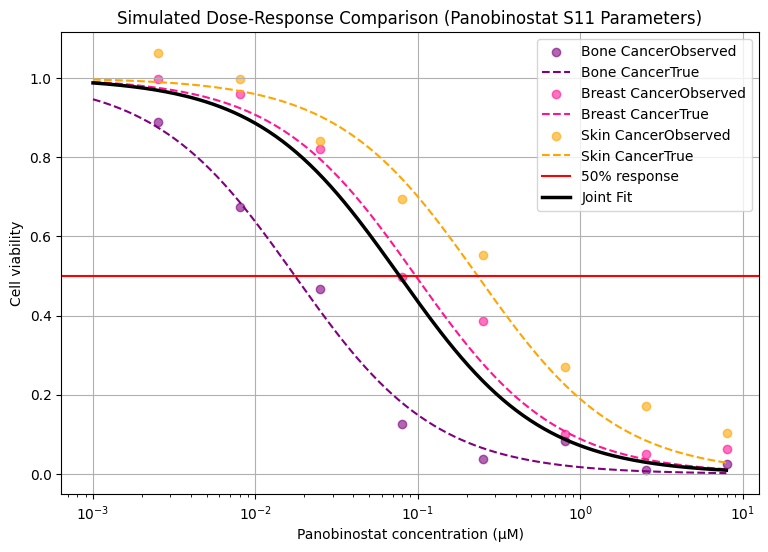

In [6]:
# Visualize dose-response for one experiment
plt.figure(figsize=(9, 6))

# Create more data points (in order to make a "smooth" curve)
fine_concentrations = []
current = 0.001
while current <= 8.0:
    fine_concentrations.append(current)
    current = current * 1.05

# Plot true dose-response curve and observed data (for each cancer type)
for c_type in cancer_types:
  color = cancer_types[c_type]["color"]
  EC50_true = cancer_types[c_type]["EC50_true"]
  observations = simulated_data[c_type]["observed_response"]
  plt.scatter(concentrations, observations, color=color, alpha=0.6, label=c_type + "Observed")

# Theoretical dose-response curve
  fine_curve = []
  for c in fine_concentrations:
    response = Hill(c, EC50_true)
    fine_curve.append(response)

  plt.plot(fine_concentrations, fine_curve, color=color, linestyle="--", label=c_type + "True")

# Visualization of the cancers together (joint dose-response curve)
joint_curve = []
for c in fine_concentrations:
  response = Hill(c, joint_fitted_EC50)
  joint_curve.append(response)

plt.axhline(0.5, color="red", linestyle="-", label="50% response")
plt.plot(fine_concentrations, joint_curve, color="black", linewidth=2.5, linestyle="-", label="Joint Fit")
plt.xscale("log")
plt.xlabel("Panobinostat concentration (µM)")
plt.ylabel("Cell viability")
plt.title("Simulated Dose-Response Comparison (Panobinostat S11 Parameters)")
plt.legend()
plt.grid(True)
plt.show()


In [7]:
# Bayesian posterior
print(" Bayesian posterior estimates for a single experiment")

bayes_samples = {}
for c_type in cancer_types:
  EC50_true = cancer_types[c_type]["EC50_true"]
  sigma = cancer_types[c_type]["sigma"]
  observations = simulated_data[c_type]["observed_response"]

# Run Bayes MCMC + save samples
  samples = sample_bayes_mcmc(concentrations, observations, sigma, initial_EC50=EC50_true)
  bayes_samples[c_type] = samples

# Calculate posterior mean
  total_samples = 0
  for sample in samples:
    total_samples = total_samples + sample

  mean_p = total_samples / len(samples)

  sorted_samples = sorted(samples)

# 95% credible interval
  lower = int(0.025 * len(sorted_samples)) # lower index
  upper = int(0.975 * len(sorted_samples)) # higher index
  ci_low = sorted_samples[lower]
  ci_high = sorted_samples[upper]

# Print results
  print()
  print("Cancer type:", c_type)
  print("True EC50:", round(EC50_true, 4), "µM")
  print("Posterior mean:", round(mean_p, 4), "µM")
  print("95% credible interval:", round(ci_low, 4), "-", round(ci_high, 4), "µM")

 Bayesian posterior estimates for a single experiment

Cancer type: Bone Cancer
True EC50: 0.0175 µM
Posterior mean: 0.0183 µM
95% credible interval: 0.015 - 0.0224 µM

Cancer type: Breast Cancer
True EC50: 0.0969 µM
Posterior mean: 0.11 µM
95% credible interval: 0.0839 - 0.1439 µM

Cancer type: Skin Cancer
True EC50: 0.2332 µM
Posterior mean: 0.2452 µM
95% credible interval: 0.184 - 0.3002 µM


In [8]:
# Monte Carlo simulation
# We repeat the experiment 500 times to investigate the spread in EC50

n_simulations = 500
mc_results = {}
for c_type in cancer_types:
  mc_results[c_type] = []

mc_results["All three cancer types"] = []

# Monte Carlo for each cancer type
for c_type in cancer_types:
  EC50_true = cancer_types[c_type]["EC50_true"]
  sigma = cancer_types[c_type]["sigma"]

  for i in range(n_simulations):
    simulated_observation = []

    for c in concentrations:
      true_response = Hill(c, EC50_true)
      noise = random.gauss(0, sigma)
      observation = true_response + noise
      simulated_observation.append(observation)

    estimated_EC50 = fit_EC50_adaptive(concentrations, simulated_observation, sigma)
    mc_results[c_type].append(estimated_EC50)

# Monte Carlo for combined data set
for i in range(n_simulations):
  pooled_observations = []

  for c_type in cancer_types:
    EC50_true = cancer_types[c_type]["EC50_true"]
    sigma = cancer_types[c_type]["sigma"]

    for c in concentrations:
      true_response = Hill(c, EC50_true)
      noise = random.gauss(0, sigma)
      observation = true_response + noise
      pooled_observations.append(observation)

  estimated_EC50 = fit_EC50_adaptive(joint_concentrations, pooled_observations, joint_sigma)
  mc_results["All three cancer types"].append(estimated_EC50)

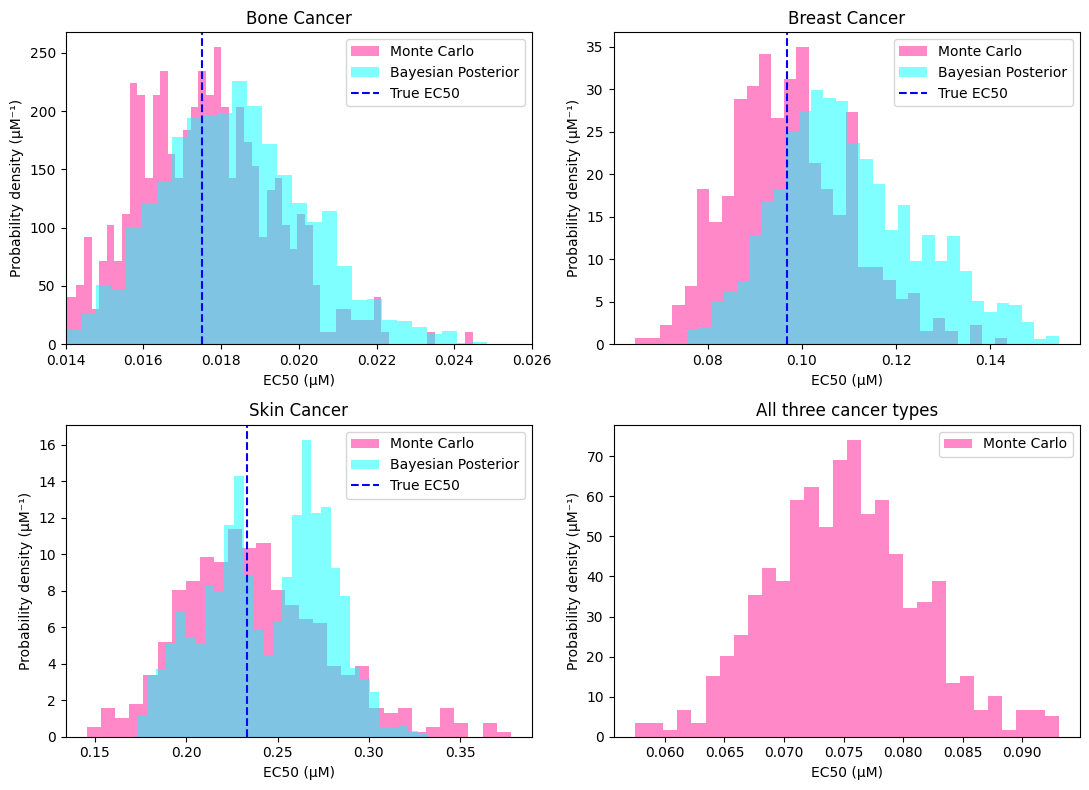

In [9]:
# Make histograms to compare bayes posterior vs monte carlo
plt.figure(figsize=(11, 8))

# Bone cancer
plt.subplot(2, 2, 1)
plt.hist(mc_results["Bone Cancer"], bins=60, color="deeppink", alpha=0.5, density=True, label="Monte Carlo")
plt.hist(bayes_samples["Bone Cancer"], bins=30, color="cyan", alpha=0.5, density=True, label="Bayesian Posterior")
plt.axvline(cancer_types["Bone Cancer"]["EC50_true"], color="blue", linestyle="--", label="True EC50")
plt.title("Bone Cancer")
plt.xlabel("EC50 (µM)")
plt.ylabel("Probability density (µM⁻¹)")
plt.xlim(0.014, 0.026)
plt.legend()

# Breast Cancer
plt.subplot(2, 2, 2)
plt.hist(mc_results["Breast Cancer"], bins=30, color="deeppink", alpha=0.5, density=True, label="Monte Carlo")
plt.hist(bayes_samples["Breast Cancer"], bins=30, color="cyan", alpha=0.5, density=True, label="Bayesian Posterior")
plt.axvline(cancer_types["Breast Cancer"]["EC50_true"], color="blue", linestyle="--", label="True EC50")
plt.title("Breast Cancer")
plt.xlabel("EC50 (µM)")
plt.ylabel("Probability density (µM⁻¹)")
plt.legend()

# Skin Cancer
plt.subplot(2, 2, 3)
plt.hist(mc_results["Skin Cancer"], bins=30, color="deeppink", alpha=0.5, density=True, label="Monte Carlo")
plt.hist(bayes_samples["Skin Cancer"], bins=30, color="cyan", alpha=0.5, density=True, label="Bayesian Posterior")
plt.axvline(cancer_types["Skin Cancer"]["EC50_true"], color="blue", linestyle="--", label="True EC50")
plt.title("Skin Cancer")
plt.xlabel("EC50 (µM)")
plt.ylabel("Probability density (µM⁻¹)")
plt.legend()

# Combined data
plt.subplot(2, 2, 4)
plt.hist(mc_results["All three cancer types"], bins=30, color="deeppink", alpha=0.5, density=True, label="Monte Carlo")
plt.title("All three cancer types")
plt.xlabel("EC50 (µM)")
plt.ylabel("Probability density (µM⁻¹)")
plt.legend()

plt.tight_layout()
plt.show()